In [ ]:
import pandas as pd
import numpy as np
import re
from datetime import datetime
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import silhouette_score, davies_bouldin_score
from scipy.spatial.distance import cdist
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/OnlineRetail.csv", encoding='ISO-8859-1')

In [ ]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [ ]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [ ]:
df.dropna(subset=['CustomerID'], inplace=True)

In [ ]:
df.isna().sum()

,0
InvoiceNo,0
StockCode,0
Description,0
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,0
Country,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 406829 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    406829 non-null  object 
 1   StockCode    406829 non-null  object 
 2   Description  406829 non-null  object 
 3   Quantity     406829 non-null  int64  
 4   InvoiceDate  406829 non-null  object 
 5   UnitPrice    406829 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      406829 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 27.9+ MB


In [ ]:
df['CustomerID'] = df['CustomerID'].astype(int)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 406829 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    406829 non-null  object 
 1   StockCode    406829 non-null  object 
 2   Description  406829 non-null  object 
 3   Quantity     406829 non-null  int64  
 4   InvoiceDate  406829 non-null  object 
 5   UnitPrice    406829 non-null  float64
 6   CustomerID   406829 non-null  int64  
 7   Country      406829 non-null  object 
dtypes: float64(1), int64(2), object(5)
memory usage: 27.9+ MB


In [ ]:
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

In [ ]:
df = df[df['Quantity'] > 0]
df = df[df['UnitPrice'] > 0]

In [ ]:
df['Total'] = df['Quantity'] * df['UnitPrice']

In [ ]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 397884 entries, 0 to 541908
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    397884 non-null  object        
 1   StockCode    397884 non-null  object        
 2   Description  397884 non-null  object        
 3   Quantity     397884 non-null  int64         
 4   InvoiceDate  397884 non-null  datetime64[ns]
 5   UnitPrice    397884 non-null  float64       
 6   CustomerID   397884 non-null  int64         
 7   Country      397884 non-null  object        
 8   Total        397884 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(2), object(4)
memory usage: 30.4+ MB


In [ ]:
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

In [ ]:
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'Total': 'sum'
}).rename(columns={'InvoiceDate': 'Recency', 'InvoiceNo': 'Frequency', 'Total': 'Monetary'})

In [ ]:
snapshot_date


Timestamp('2011-12-10 12:50:00')

In [ ]:
rfm

,Recency,Frequency,Monetary
CustomerID,,,
12346,326,1,77183.60
12347,2,7,4310.00
12348,75,4,1797.24
12349,19,1,1757.55
12350,310,1,334.40
...,...,...,...
18280,278,1,180.60
18281,181,1,80.82
18282,8,2,178.05


In [ ]:
rfm = df.groupby('CustomerID').agg(recency = ('InvoiceDate', lambda x: (snapshot_date - x.max()).days),
                                    frequency = ('InvoiceNo', 'nunique'),
                                    monetary = ('Total', 'sum'))

In [ ]:
rfm

,recency,frequency,monetary
CustomerID,,,
12346,326,1,77183.60
12347,2,7,4310.00
12348,75,4,1797.24
12349,19,1,1757.55
12350,310,1,334.40
...,...,...,...
18280,278,1,180.60
18281,181,1,80.82
18282,8,2,178.05


In [ ]:
# 9. Average basket size (number of items per invoice)
basket = df.groupby(['CustomerID', 'InvoiceNo'])['Quantity'].sum().groupby('CustomerID').mean()
rfm['AvgBasketSize'] = basket


In [ ]:
# 10. Number of unique products purchased
unique_products = df.groupby('CustomerID')['StockCode'].nunique()
rfm['UniqueProducts'] = unique_products

In [ ]:
desc_per_customer = df.groupby('CustomerID')['Description'].apply(lambda x: ' '.join(str(d) for d in x))

tfidf = TfidfVectorizer(max_features=25, stop_words='english')
tfidf_matrix = tfidf.fit_transform(desc_per_customer)
tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), index=desc_per_customer.index, columns=tfidf.get_feature_names_out())

In [ ]:
# 12. Final DataFrame: combine all features
final_df = pd.concat([rfm, tfidf_df], axis=1)

In [ ]:
final_df.iloc

,recency,frequency,monetary,AvgBasketSize,UniqueProducts,bag,blue,box,cake,card,...,paper,pink,red,retrospot,set,sign,small,vintage,white,wooden
CustomerID,,,,,,,,,,,,,,,,,,,,,
12346,326,1,77183.60,74215.000000,1,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
12347,2,7,4310.00,351.142857,103,0.450572,0.055661,0.106770,0.267287,0.070641,...,0.000000,0.239193,0.363180,0.101410,0.411495,0.025962,0.098615,0.472693,0.071646,0.061315
12348,75,4,1797.24,585.250000,22,0.000000,0.059290,0.000000,0.610100,0.000000,...,0.132055,0.163791,0.050460,0.054011,0.140889,0.000000,0.000000,0.104175,0.000000,0.000000
12349,19,1,1757.55,631.000000,73,0.041242,0.040758,0.195459,0.167764,0.000000,...,0.045390,0.075065,0.416258,0.445550,0.548835,0.000000,0.129982,0.214842,0.078695,0.044899
12350,310,1,334.40,197.000000,17,0.159387,0.315034,0.151077,0.000000,0.000000,...,0.000000,0.145051,0.268117,0.143492,0.000000,0.661241,0.000000,0.138383,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18280,278,1,180.60,45.000000,10,0.372905,0.000000,0.000000,0.000000,0.000000,...,0.410413,0.000000,0.313646,0.335717,0.291912,0.000000,0.000000,0.323763,0.355775,0.405970
18281,181,1,80.82,54.000000,7,0.226513,0.000000,0.000000,0.000000,0.852313,...,0.000000,0.000000,0.000000,0.000000,0.354631,0.000000,0.000000,0.000000,0.000000,0.000000
18282,8,2,178.05,51.500000,12,0.000000,0.000000,0.000000,0.636497,0.392512,...,0.344422,0.284797,0.000000,0.000000,0.244975,0.000000,0.000000,0.271705,0.000000,0.000000


In [ ]:
# 13. Feature scaling
scaler = StandardScaler()
final_scaled = pd.DataFrame(scaler.fit_transform(final_df), index=final_df.index, columns=final_df.columns.astype(str))

In [ ]:
pca = PCA(n_components=10)
final_pca = pd.DataFrame(pca.fit_transform(final_scaled), index=final_scaled.index)

In [ ]:
final_pca.shape

(4338, 10)

In [ ]:
final_pca.head()

,0,1,2,3,4,5,6,7,8,9
CustomerID,,,,,,,,,,
12346,-1.883466,3.518783,-0.355026,3.203595,2.040695,-27.729468,-20.155745,14.917627,0.906311,-15.967857
12347,-1.288403,0.617093,-0.944526,-0.463648,-0.080223,0.286590,-0.034292,-0.027442,0.572949,0.868574
12348,-1.257320,-1.944691,-1.915699,0.995263,-1.014694,-2.750197,-0.150012,-1.536358,-1.127179,2.267597
12349,-0.827131,-0.001137,-1.346472,-0.194223,-1.575478,1.449878,-0.804634,-0.816914,-0.039926,-1.249671
12350,0.515377,-0.693184,2.823552,4.755187,0.211955,1.053207,-0.554283,0.419720,1.462414,0.098084


## Clustering Techniques

In [ ]:
def initialize_centroids(X, k):
    np.random.seed(42)
    indices = np.random.choice(len(X), k, replace=False)
    return X[indices]

def assign_clusters(X, centroids):
    distances = cdist(X, centroids, 'euclidean')
    return np.argmin(distances, axis=1)

def update_centroids(X, labels, k):
    return np.array([X[labels == i].mean(axis=0) for i in range(k)])

def kmeans(X, k, max_iters=100):
    centroids = initialize_centroids(X, k)
    for _ in range(max_iters):
        labels = assign_clusters(X, centroids)
        new_centroids = update_centroids(X, labels, k)
        if np.allclose(centroids, new_centroids):
            break
        centroids = new_centroids
    return labels, centroids

In [ ]:
# ----- DBSCAN FROM SCRATCH -----
def dbscan(X, eps, min_pts):
    labels = np.full(len(X), -1)
    cluster_id = 0
    visited = set()

    def region_query(point_idx):
        return np.where(np.linalg.norm(X - X[point_idx], axis=1) <= eps)[0]

    def expand_cluster(point_idx, neighbors):
        nonlocal cluster_id
        labels[point_idx] = cluster_id
        i = 0
        while i < len(neighbors):
            n = neighbors[i]
            if n not in visited:
                visited.add(n)
                n_neighbors = region_query(n)
                if len(n_neighbors) >= min_pts:
                    neighbors = np.append(neighbors, n_neighbors)
            if labels[n] == -1:
                labels[n] = cluster_id
            i += 1

    for idx in range(len(X)):
        if idx in visited:
            continue
        visited.add(idx)
        neighbors = region_query(idx)
        if len(neighbors) < min_pts:
            labels[idx] = -1  # Noise
        else:
            expand_cluster(idx, neighbors)
            cluster_id += 1

    return labels

In [ ]:
# ----- HIERARCHICAL CLUSTERING -----
def hierarchical_clustering(X, n_clusters):
    Z = linkage(X, method='ward')
    labels = fcluster(Z, n_clusters, criterion='maxclust')
    return labels, Z

In [ ]:
# ----- EVALUATION METRICS -----
def evaluate_clustering(X, labels):
    if len(set(labels)) > 1 and len(set(labels)) < len(X):
        silhouette = silhouette_score(X, labels)
        dbi = davies_bouldin_score(X, labels)
    else:
        silhouette = -1
        dbi = np.inf
    return silhouette, dbi

In [ ]:
# ----- RUNNING ON final_pca DATA -----
X = final_pca.values

In [ ]:
# KMeans
kmeans_labels, _ = kmeans(X, k=4)
kmeans_sil, kmeans_dbi = evaluate_clustering(X, kmeans_labels)

In [ ]:
# DBSCAN
dbscan_labels = dbscan(X, eps=3.5, min_pts=5)
dbscan_sil, dbscan_dbi = evaluate_clustering(X, dbscan_labels)

In [ ]:
# Hierarchical
hier_labels, Z = hierarchical_clustering(X, n_clusters=4)
hier_sil, hier_dbi = evaluate_clustering(X, hier_labels)


In [ ]:
# Print evaluation results
print("KMeans: Silhouette =", kmeans_sil, ", DBI =", kmeans_dbi)
print("DBSCAN: Silhouette =", dbscan_sil, ", DBI =", dbscan_dbi)
print("Hierarchical: Silhouette =", hier_sil, ", DBI =", hier_dbi)


KMeans: Silhouette = 0.17040538885711526 , DBI = 1.8644174927062032
DBSCAN: Silhouette = 0.6825493424979034 , DBI = 0.9552792260613711
Hierarchical: Silhouette = 0.1094262488965767 , DBI = 2.2199939356002396


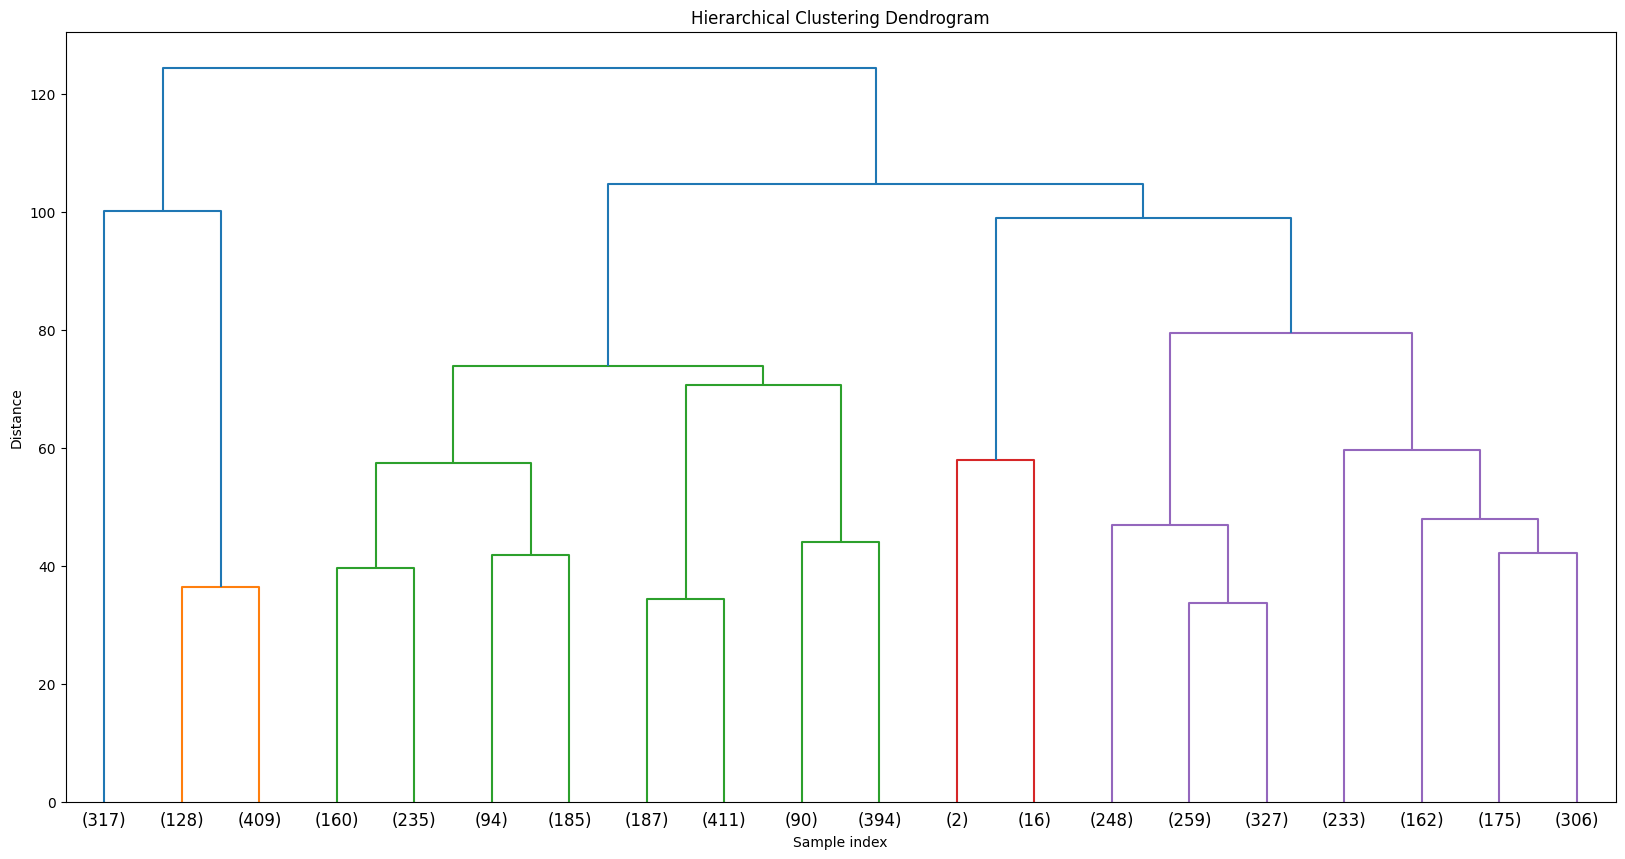

In [ ]:
# Optional: Dendrogram plot
plt.figure(figsize=(20, 10))
dendrogram(Z, truncate_mode='lastp', p=20)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Sample index")
plt.ylabel("Distance")
plt.show()
